# Iris Dataset Clustering & PCA

This notebook performs K-Means clustering and Principal Component Analysis (PCA) on the classic Iris flowers dataset. We reduce the 4-dimensional features to 2 principal components and verify how well the unsupervised clusters correspond to the actual species.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
raw_data = load_iris()
X = raw_data.data
y = raw_data.target
feature_names = raw_data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [raw_data.target_names[idx] for idx in y]
df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Principal Component Analysis (PCA)

We reduce the feature dimensions from 4 to 2 to visualize the dataset on a 2D plane.



In [2]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
explained_var = pca.explained_variance_ratio_

print(f"Explained Variance Ratio: Component 1 = {explained_var[0]*100:.1f}%, Component 2 = {explained_var[1]*100:.1f}%")
print(f"Total Explained Variance: {sum(explained_var)*100:.1f}%")



Explained Variance Ratio: Component 1 = 92.5%, Component 2 = 5.3%
Total Explained Variance: 97.8%


## Unsupervised K-Means Clustering

We fit a K-Means model with 3 clusters and plot the clusters along with their centroids against the actual species labels.



<cell>:35: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



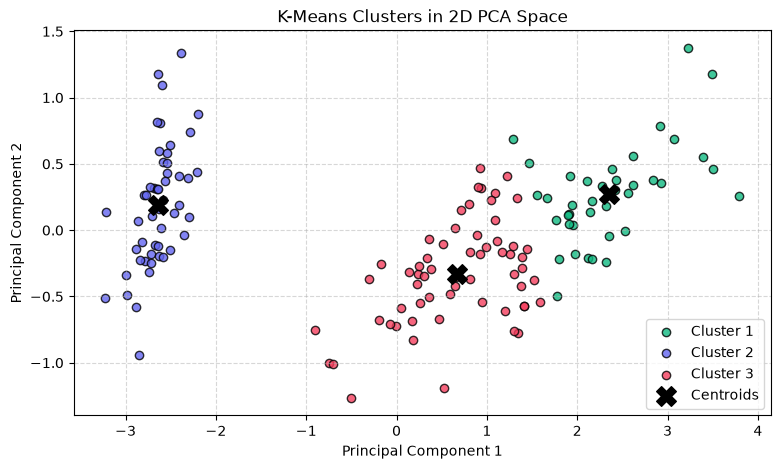

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Plotting
plt.figure(figsize=(9, 5))
colors = ['#10B981', '#6366F1', '#F43F5E']

# Plot PCA points colored by K-Means clusters
for i in range(3):
    plt.scatter(
        X_pca[clusters == i, 0], 
        X_pca[clusters == i, 1], 
        color=colors[i], 
        label=f'Cluster {i+1}', 
        alpha=0.8, 
        edgecolors='k'
    )

# Plot Centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    color='black', 
    marker='X', 
    s=200, 
    label='Centroids'
)

plt.title("K-Means Clusters in 2D PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
